## Social Media Sentiment Analysis Using NLP and ML
#### 
Social media platforms contain a large amount of user-generated text expressing different opinions, emotions, and experiences. Analyzing this text manually is difficult when the amount of data is large. Sentiment Analysis helps identify whether a piece of text expresses a Positive, Negative, or Neutral sentiment.

This project uses Natural Language Processing (NLP) and machine learning techniques to automatically classify social media posts into three sentiment categories: Positive, Negative, and Neutral.

The project uses the SocialMediasentimentdataset, which contains user-generated text along with information such as sentiment, timestamp, platform, country, likes, and retweets. The main focus of the machine learning task is to use the Text column to predict the Sentiment.

In [1]:
#pip install pandas numpy matplotlib seaborn scikit-learn nltk

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import nltk
nltk.download("punkt")
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Load dataset
df = pd.read_csv("SocialMediasentimentdataset.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (732, 15)


In [5]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [7]:
print("Null Values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Null Values: 0
Duplicate rows: 0


In [8]:
#Value Counts — Sentiment and Platform
print(df["Sentiment"].value_counts())

Sentiment
Positive           44
Joy                42
Excitement         32
Neutral            14
Contentment        14
                   ..
Adrenaline          1
Harmony             1
ArtisticBurst       1
Radiance            1
Elegance            1
Name: count, Length: 279, dtype: int64


In [9]:
#Sentiment percentage
sentiment_percent = df["Sentiment"].value_counts(normalize=True) * 100

print(sentiment_percent.round(2))

Sentiment
Positive           6.01
Joy                5.74
Excitement         4.37
Neutral            1.91
Contentment        1.91
                   ... 
Adrenaline         0.14
Harmony            0.14
ArtisticBurst      0.14
Radiance           0.14
Elegance           0.14
Name: proportion, Length: 279, dtype: float64


In [10]:
#Platform distribution
print(df["Platform"].value_counts())

Platform
Instagram     258
Facebook      231
Twitter       128
Twitter       115
Name: count, dtype: int64


In [11]:
print(pd.crosstab(df["Platform"], df["Sentiment"]))

Sentiment   Acceptance     Acceptance        Accomplishment   Admiration   \
Platform                                                                    
Facebook                2                 2                3            0   
Instagram               0                 2                0            1   
Twitter                 0                 0                0            0   
Twitter                 1                 1                0            0   

Sentiment   Admiration     Admiration      Adoration      Adrenaline       \
Platform                                                                    
Facebook                0               0              0                1   
Instagram               0               1              0                0   
Twitter                 0               0              0                0   
Twitter                 2               0              2                0   

Sentiment   Adventure   Affection      ...  Vibrancy   Whimsy          \
P

In [12]:
# Display all unique sentiment labels

sentiments = sorted(df["Sentiment"].dropna().unique())

for i, sentiment in enumerate(sentiments, 1):
    print(i, ":", sentiment)

1 :  Acceptance   
2 :  Acceptance      
3 :  Accomplishment 
4 :  Admiration 
5 :  Admiration   
6 :  Admiration    
7 :  Adoration    
8 :  Adrenaline     
9 :  Adventure 
10 :  Affection    
11 :  Amazement 
12 :  Ambivalence 
13 :  Ambivalence     
14 :  Amusement    
15 :  Amusement     
16 :  Anger        
17 :  Anticipation 
18 :  Anticipation  
19 :  Anxiety   
20 :  Anxiety         
21 :  Appreciation  
22 :  Apprehensive 
23 :  Arousal       
24 :  ArtisticBurst 
25 :  Awe 
26 :  Awe    
27 :  Awe          
28 :  Awe           
29 :  Bad 
30 :  Betrayal 
31 :  Betrayal      
32 :  Bitter       
33 :  Bitterness 
34 :  Bittersweet 
35 :  Blessed       
36 :  Boredom 
37 :  Boredom         
38 :  Breakthrough 
39 :  Calmness     
40 :  Calmness      
41 :  Captivation 
42 :  Celebration 
43 :  Celestial Wonder 
44 :  Challenge 
45 :  Charm 
46 :  Colorful 
47 :  Compassion
48 :  Compassion    
49 :  Compassionate 
50 :  Confidence    
51 :  Confident 
52 :  Confusion 
53 :  Con

In [13]:
# Clean original sentiment labels

df["Sentiment"] = df["Sentiment"].str.strip()

In [14]:
positive_labels = [
    "Acceptance", "Accomplishment", "Admiration", "Adoration",
    "Adrenaline", "Adventure", "Affection", "Amazement",
    "Anticipation", "Appreciation", "ArtisticBurst", "Awe",
    "Blessed", "Breakthrough", "Calmness", "Captivation",
    "Celebration", "Charm", "Colorful", "Compassion",
    "Compassionate", "Confidence", "Confident", "Connection",
    "Contentment", "Coziness", "Creative Inspiration",
    "Creativity", "Culinary Adventure", "CulinaryOdyssey",
    "Curiosity", "Dazzle", "Determination", "DreamChaser",
    "Ecstasy", "Elation", "Elegance", "Empowerment",
    "Enchantment", "Energy", "Enjoyment", "Engagement",
    "Enthusiasm", "Euphoria", "Excitement", "Exploration",
    "FestiveJoy", "Free-spirited", "Freedom", "Friendship",
    "Fulfillment", "Grandeur", "Grateful", "Gratitude",
    "Happiness", "Happy", "Harmony", "Heartwarming",
    "Hope", "Hopeful", "Hypnotic", "Iconic", "Imagination",
    "Immersion", "Inspiration", "Inspired", "Intrigue",
    "Joy", "Joy in Baking", "JoyfulReunion", "Kind",
    "Kindness", "Love", "Marvel", "Melodic", "Mesmerizing",
    "Mindfulness", "Motivation", "Nature's Beauty",
    "Ocean's Freedom", "Optimism", "Overjoyed", "Playful",
    "PlayfulJoy", "Positive", "Positivity", "Pride", "Proud",
    "Radiance", "Rejuvenation", "Relief", "Renewed Effort",
    "Resilience", "Reverence", "Romance", "Runway Creativity",
    "Satisfaction", "Serenity", "Solace", "Spark", "Success",
    "Surprise", "Sympathy", "Tenderness", "Thrill",
    "Thrilling Journey", "Touched", "Tranquility", "Triumph",
    "Vibrancy", "Whimsy", "Winter Magic", "Wonder",
    "Wonderment", "Zest", "Amusement",
    "Celestial Wonder","Empathetic","Envisioning History",
    "InnerJourney","Mischievous","Nostalgia","Whispers of the Past"
]

In [15]:
negative_labels = [
    "Anger", "Anxiety", "Apprehensive", "Bad", "Betrayal",
    "Bitter", "Bitterness", "Boredom", "Darkness", "Desolation",
    "Despair", "Desperation", "Devastated", "Disappointed",
    "Disappointment", "Disgust", "Dismissive", "Embarrassed",
    "EmotionalStorm", "Envious", "Envy", "Exhaustion", "Fear",
    "Fearful", "Frustrated", "Frustration", "Grief", "Hate",
    "Heartache", "Heartbreak", "Helplessness", "Intimidation",
    "Isolation", "Jealous", "Jealousy", "Loneliness", "Loss",
    "LostLove", "Melancholy", "Miscalculation", "Negative",
    "Numbness", "Obstacle", "Overwhelmed", "Pressure",
    "Regret", "Resentment", "Ruins", "Sad", "Sadness",
    "Shame", "Sorrow", "Suffering", "Yearning", "Solitude", "Solitude"
]

In [16]:
neutral_labels = [
    "Ambivalence","Arousal", "Bittersweet","Challenge",
    "Confusion","Contemplation","Emotion","Indifference",
    "Journey","Pensive","Reflection","Suspense","Neutral"
]

In [17]:
def convert_sentiment(label):
    
    if label in positive_labels:
        return "Positive"
    
    elif label in negative_labels:
        return "Negative"
    
    else:
        return "Neutral"

In [18]:
df["Sentiment_3Class"] = df["Sentiment"].apply(convert_sentiment)
print(df["Sentiment_3Class"].value_counts())

Sentiment_3Class
Positive    489
Negative    188
Neutral      55
Name: count, dtype: int64


In [19]:
mapped_labels = set(positive_labels + negative_labels + neutral_labels)

unmapped_labels = sorted(
    set(df["Sentiment"].unique()) - mapped_labels
)

print("Unmapped labels:")
print(unmapped_labels)

Unmapped labels:
[]


In [20]:
def convert_sentiment(label):
    
    if label in positive_labels:
        return "Positive"
    
    elif label in negative_labels:
        return "Negative"
    
    elif label in neutral_labels:
        return "Neutral"
    
    else:
        return "Unknown"

In [21]:
df["Sentiment_3Class"] = df["Sentiment"].apply(convert_sentiment)

print(df["Sentiment_3Class"].value_counts())

Sentiment_3Class
Positive    489
Negative    188
Neutral      55
Name: count, dtype: int64


In [22]:
# Text Preprocessing
# Check original text
df[["Text", "Sentiment_3Class"]].head()

,Text,Sentiment_3Class
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


In [23]:
# Load English stopwords
stop_words = set(stopwords.words("english"))

In [27]:
import re
from nltk.corpus import stopwords

# Load stopwords
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove punctuation, numbers and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words
    return " ".join(words)

In [28]:
df["Clean_Text"] = df["Text"].apply(preprocess_text)

df[["Text", "Clean_Text", "Sentiment_3Class"]].head(10)

,Text,Clean_Text,Sentiment_3Class
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,Positive
1,Traffic was terrible this morning. ...,traffic terrible morning,Negative
2,Just finished an amazing workout! 💪 ...,finished amazing workout,Positive
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,Positive
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,Neutral
5,Feeling grateful for the little things in lif...,feeling grateful little things life,Positive
6,Rainy days call for cozy blankets and hot coc...,rainy days call cozy blankets hot cocoa,Positive
7,The new movie release is a must-watch! ...,new movie release mustwatch,Positive
8,Political discussions heating up on the timel...,political discussions heating timeline,Negative
9,Missing summer vibes and beach days. ...,missing summer vibes beach days,Neutral


In [29]:
print("Empty cleaned texts:", (df["Clean_Text"].str.strip() == "").sum())

Empty cleaned texts: 0


In [30]:
for i in range(5):
    print("Original:", df["Text"].iloc[i])
    print("Cleaned :", df["Clean_Text"].iloc[i])
    print()

Original:  Enjoying a beautiful day at the park!              
Cleaned : enjoying beautiful day park

Original:  Traffic was terrible this morning.                 
Cleaned : traffic terrible morning

Original:  Just finished an amazing workout! 💪               
Cleaned : finished amazing workout

Original:  Excited about the upcoming weekend getaway!        
Cleaned : excited upcoming weekend getaway

Original:  Trying out a new recipe for dinner tonight.        
Cleaned : trying new recipe dinner tonight



In [50]:
df["Platform"] = df["Platform"].str.strip()

platform_df = pd.crosstab(
    df["Platform"],
    df["Sentiment_3Class"]
).reindex(columns=["Negative", "Neutral", "Positive"], fill_value=0)

print(platform_df)

Sentiment_3Class  Negative  Neutral  Positive
Platform                                     
Facebook                58       17       156
Instagram               64       21       173
Twitter                 66       17       160


In [51]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X = df["Clean_Text"]
y = df["Sentiment_3Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 585
Testing size: 147


In [52]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (585, 5000)
Testing TF-IDF shape: (147, 5000)


In [53]:
#Model Selection and Implementation
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

nb_model = MultinomialNB()

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

In [54]:
#Train models
lr_model.fit(X_train_tfidf, y_train)
nb_model.fit(X_train_tfidf, y_train)
svm_model.fit(X_train_tfidf, y_train)

print("All models trained successfully.")

All models trained successfully.


In [55]:
#Predictions
lr_pred = lr_model.predict(X_test_tfidf)
nb_pred = nb_model.predict(X_test_tfidf)
svm_pred = svm_model.predict(X_test_tfidf)

In [56]:
#Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1-Score": f1_score(y_true, y_pred, average="weighted")
    }

results = [
    evaluate_model("Logistic Regression", y_test, lr_pred),
    evaluate_model("Multinomial Naive Bayes", y_test, nb_pred),
    evaluate_model("Linear SVM", y_test, svm_pred)
]

results_df = pd.DataFrame(results)

results_df.round(4)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8503,0.8392,0.8503,0.8332
1,Multinomial Naive Bayes,0.7551,0.7461,0.7551,0.6950
2,Linear SVM,0.8639,0.8819,0.8639,0.8434


In [57]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("Multinomial Naive Bayes")
print(classification_report(y_test, nb_pred))

print("Linear SVM")
print(classification_report(y_test, svm_pred))

Logistic Regression
              precision    recall  f1-score   support

    Negative       0.93      0.74      0.82        38
     Neutral       0.50      0.18      0.27        11
    Positive       0.84      0.97      0.90        98

    accuracy                           0.85       147
   macro avg       0.76      0.63      0.66       147
weighted avg       0.84      0.85      0.83       147

Multinomial Naive Bayes
              precision    recall  f1-score   support

    Negative       1.00      0.34      0.51        38
     Neutral       0.00      0.00      0.00        11
    Positive       0.73      1.00      0.84        98

    accuracy                           0.76       147
   macro avg       0.58      0.45      0.45       147
weighted avg       0.75      0.76      0.70       147

Linear SVM
              precision    recall  f1-score   support

    Negative       0.97      0.74      0.84        38
     Neutral       1.00      0.18      0.31        11
    Positive       0

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


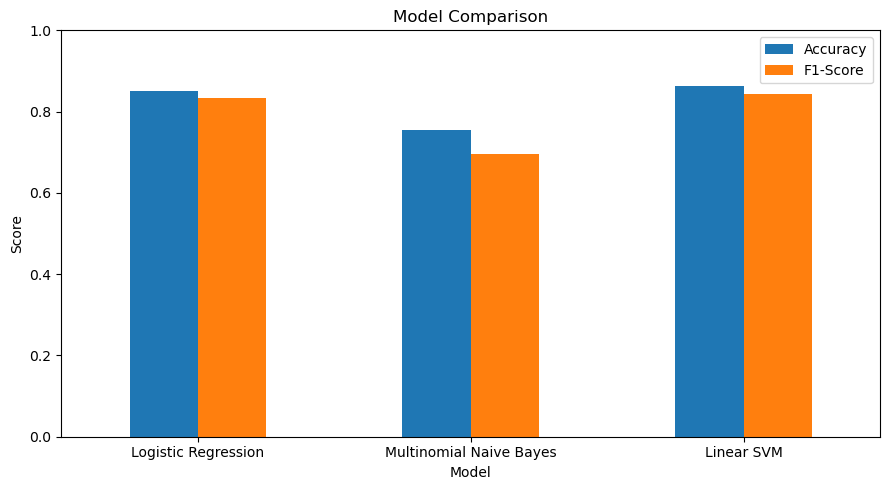

In [58]:
#Model Comparison Graph

results_plot = results_df.set_index("Model")

results_plot[["Accuracy", "F1-Score"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:
#Best Model + Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(), "Model"
]

predictions = {
    "Logistic Regression": lr_pred,
    "Multinomial Naive Bayes": nb_pred,
    "Linear SVM": svm_pred
}

best_pred = predictions[best_model_name]

print("Best Model:", best_model_name)

Best Model: Linear SVM


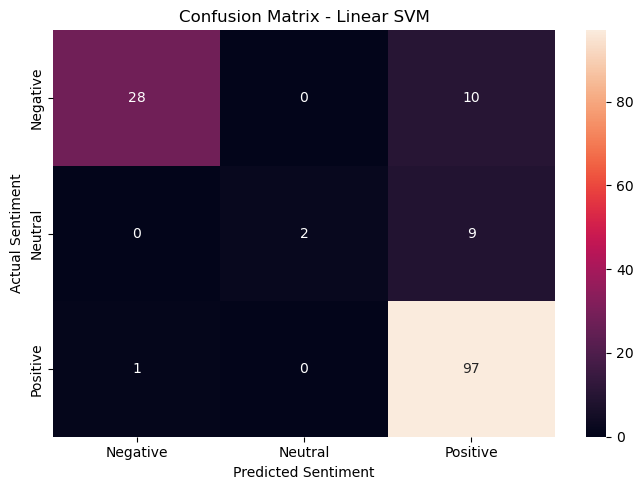

In [60]:
labels = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

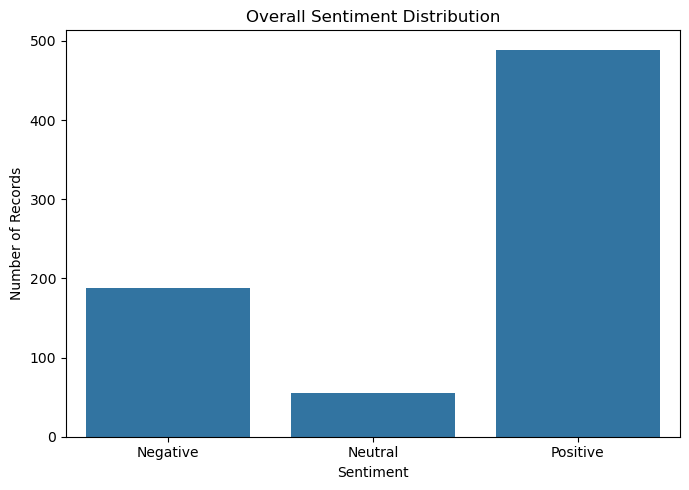

In [61]:
#Sentiment Distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sentiment_3Class",
    order=["Negative", "Neutral", "Positive"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

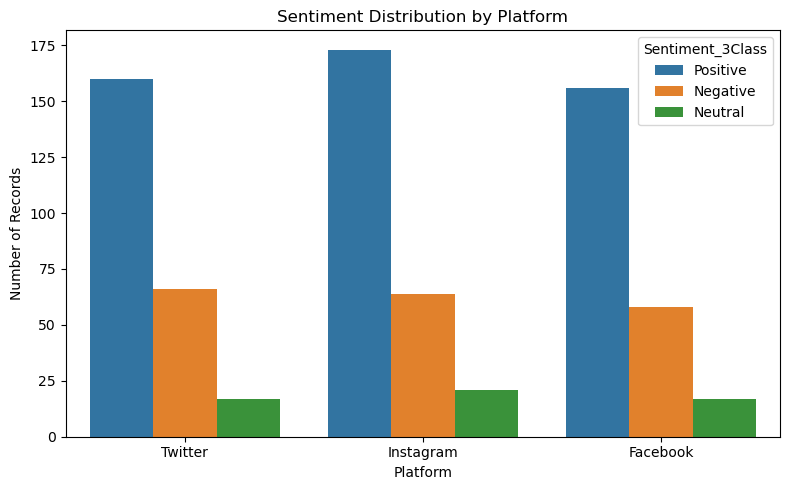

In [62]:
#Sentiment by Platform
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Platform",
    hue="Sentiment_3Class"
)

plt.title("Sentiment Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [63]:
#Final Result Summary
print("Final Model Comparison")
display(results_df.round(4))

print("\nSelected Model:", best_model_name)

Final Model Comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8503,0.8392,0.8503,0.8332
1,Multinomial Naive Bayes,0.7551,0.7461,0.7551,0.6950
2,Linear SVM,0.8639,0.8819,0.8639,0.8434



Selected Model: Linear SVM


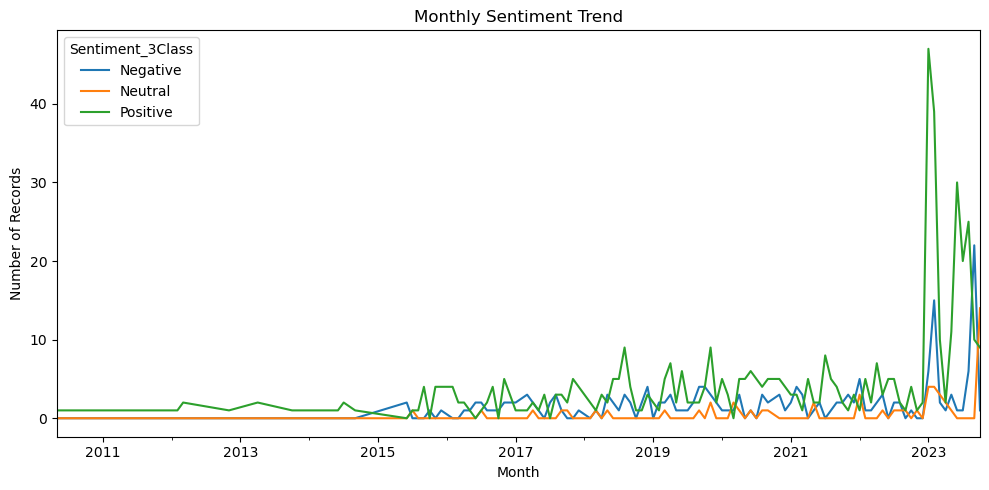

In [64]:
#Monthly Sentiment Trend
df["Date"] = pd.to_datetime(
    df[["Year", "Month", "Day"]]
)

monthly_sentiment = (
    df.groupby([
        df["Date"].dt.to_period("M"),
        "Sentiment_3Class"
    ])
    .size()
    .unstack(fill_value=0)
)

monthly_sentiment.plot(figsize=(10, 5))

plt.title("Monthly Sentiment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()